# Phase 1 — Final Data & Feature Engineering Notebook

**Defense protocol:** real StatsBomb/Football-Data rows only; no synthetic fallback in the final run.  
Feature families are not added because “they looked useful”: each family has a domain reason, an availability/leakage screen, and a future-season RPS decision.

In [1]:
from pathlib import Path
import sys, json, pandas as pd, numpy as np
from IPython.display import display, Image

HERE = Path.cwd().resolve()
ROOT = next((p for p in [HERE, *HERE.parents] if (p / "phase1").exists() and (p / "phase2").exists()), None)
if ROOT is None:
    raise RuntimeError("Run this notebook from inside the extracted project folder.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: /mnt/data/ML_final_FINAL_v2_work/ml_final_work


In [2]:
from phase1.final_feature_engineering import run
result = run(ROOT)
print("Phase 1 final pipeline completed.")

  Attempting fuzzy fallback for 2 unmatched matches...
  Attempting fuzzy fallback for 6 unmatched matches...
  Attempting fuzzy fallback for 8 unmatched matches...
  Attempting fuzzy fallback for 6 unmatched matches...


Phase 1 final pipeline completed.


## 1. Real-data scope and reproducibility

In [3]:
display(result["report"])
assert int(result["report"].set_index("metric").loc["synthetic_rows_used", "value"]) == 0
print("REAL_DATA_ONLY assertion: PASS")

,metric,value
0,raw_matches_cached,138
1,pre_match_modeling_rows,111
2,in_play_snapshots,1998
3,odds_tagged_rows,111
4,odds_coverage,1.0
5,selected_feature_groups,"core_form, style"
6,selected_feature_count,11
7,synthetic_rows_used,0
8,final_test_season_reserved,2020/2021


REAL_DATA_ONLY assertion: PASS


## 2. Odds integration and de-vigged market baseline

In [4]:
display(result["coverage"])
print("Excluded odds matches:", len(result["excluded"]))
display(result["market"].round(4))

,season,year,matches,tagged,coverage_rate
0,2017/2018,2018,17,17,1.0
1,2018/2019,2018,13,13,1.0
2,2018/2019,2019,18,18,1.0
3,2019/2020,2019,11,11,1.0
4,2019/2020,2020,19,19,1.0
5,2020/2021,2020,13,13,1.0
6,2020/2021,2021,20,20,1.0


Excluded odds matches: 0


,season,n_matches,coverage,accuracy,balanced_accuracy,rps,log_loss
0,2017/2018,17,1.0,0.6471,0.6667,0.1131,0.8009
1,2018/2019,31,1.0,0.6774,0.6077,0.1461,0.8395
2,2019/2020,30,1.0,0.7333,0.6250,0.1244,0.7046
3,2020/2021,33,1.0,0.6364,0.5183,0.1848,0.9132


## 3. Why each feature family was kept or rejected

In [5]:
display(result["rationale"])
display(result["selection"].decisions.round(4))
print("Selected groups:", result["selection"].selected_groups)
print("Selected features (n=%d):" % len(result["selection"].selected_features))
for f in result["selection"].selected_features: print(" -", f)

,feature_family,decision,evidence,leakage_status
0,market odds,BASELINE_ONLY,100% identity-tagging target; excluded from mo...,pre-match identity only
1,home/away mirrored raw columns,COMPRESS_TO_DIFFERENCES,paired football quantities describe the same c...,history only
2,momentum,REJECT,mean missingness across raw momentum columns=4...,history only but insufficient availability
3,core_form,KEEP,6 features; development mean RPS=0.1606; delta...,all aggregates shifted to matches completed be...
4,style,KEEP,5 features; development mean RPS=0.1458; delta...,all aggregates shifted to matches completed be...
5,defense_setpiece,REJECT,4 features; development mean RPS=0.1555; delta...,all aggregates shifted to matches completed be...
6,short_form,REJECT,3 features; development mean RPS=0.1472; delta...,all aggregates shifted to matches completed be...
7,context,REJECT,2 features; development mean RPS=0.1451; delta...,all aggregates shifted to matches completed be...
8,efficiency,REJECT,4 features; development mean RPS=0.1471; delta...,all aggregates shifted to matches completed be...


,step,group,action,mean_dev_rps,delta_rps,n_features_after,reason
0,0,momentum,REJECT,NaN,NaN,0,pre-screen rejection: mean missingness=0.423 (...
1,1,core_form,KEEP,0.1606,NaN,6,domain anchor: prior five-match points/goals/s...
2,2,style,KEEP,0.1458,0.0147,11,earned its complexity: mean future-season deve...
3,3,context,REJECT,0.1451,0.0007,11,no out-of-season RPS gain >= 0.0010; rejected ...
4,3,efficiency,REJECT,0.1471,-0.0013,11,no out-of-season RPS gain >= 0.0010; rejected ...
5,3,short_form,REJECT,0.1472,-0.0014,11,no out-of-season RPS gain >= 0.0010; rejected ...
6,3,defense_setpiece,REJECT,0.1555,-0.0096,11,no out-of-season RPS gain >= 0.0010; rejected ...


Selected groups: ['core_form', 'style']
Selected features (n=11):
 - diff_form5_points_final
 - diff_form5_goals_for_final
 - diff_form5_goals_against_final
 - diff_form5_shots_for_final
 - diff_form5_xg_for_final
 - diff_form5_xg_against_final
 - diff_form5_passes_final
 - diff_form5_completed_passes_final
 - diff_form5_pressures_final
 - diff_form5_carries_final_third_final
 - diff_form5_event_share_final


### Decision rule used in the defense
- **Core form is the domain anchor**: prior 5-match points/goals/shots/xG, all shifted before kick-off.
- An extra group is kept only if it improves mean RPS on **future-season development folds** by at least **0.001**.
- Momentum is rejected before modeling because its mean missingness is above 30% in this small subset.
- Market probabilities are **baseline-only**, never mixed into the model whose performance is compared with the market.

## 4. Leakage checks already produced by the raw pipeline

In [6]:
leak = pd.read_csv(ROOT / "phase1" / "outputs" / "leakage_audit.csv")
display(leak)
assert leak["passed"].astype(bool).all()
print("Leakage audit: PASS")

,check,passed
0,Pre-match history strictly before kick-off,True
1,In-play event timestamp <= snapshot time,True
2,GMMSampling called only on training partition,True


Leakage audit: PASS


## 5. Saved Phase 1 outputs

In [7]:
for name in [
    "pre_match_features_final.csv", "selected_features_final.csv",
    "feature_selection_decisions_final.csv", "feature_rationale_final.csv",
    "odds_coverage_final.csv", "market_baseline_final.csv"]:
    p = ROOT / "phase1" / "outputs" / name
    print("OK" if p.exists() else "MISSING", p.relative_to(ROOT))

OK phase1/outputs/pre_match_features_final.csv
OK phase1/outputs/selected_features_final.csv
OK phase1/outputs/feature_selection_decisions_final.csv
OK phase1/outputs/feature_rationale_final.csv
OK phase1/outputs/odds_coverage_final.csv
OK phase1/outputs/market_baseline_final.csv


## 6. Defense-ready charts — shown inline

این بخش عمداً داخل همین Notebook قرار گرفته است تا برای ارائه لازم نباشد وارد پوشه `outputs/` شوید. همه‌ی نمودارهای زیر از فایل‌های **final** فاز ۱ ساخته می‌شوند؛ بنابراین با **Run All** دوباره همان‌جا نمایش داده می‌شوند.

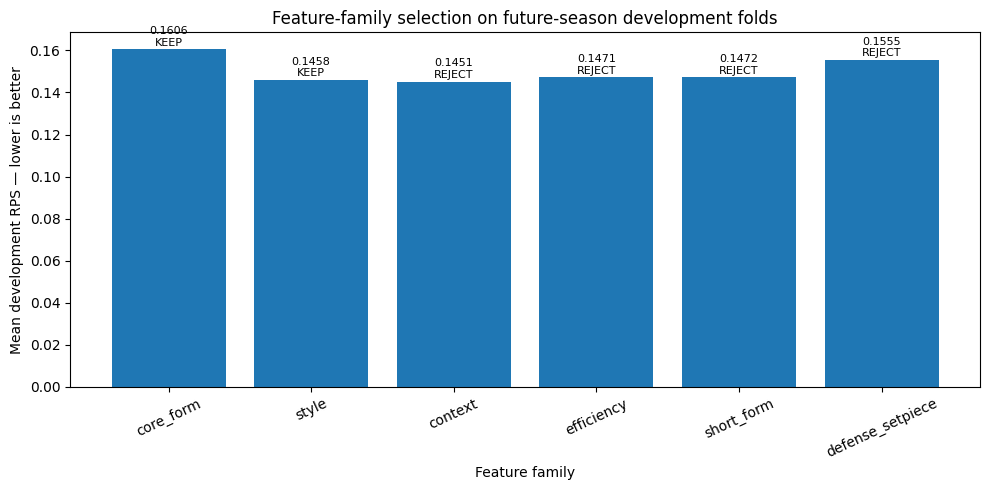

Decision threshold for an additional group: RPS improvement >= 0.0010
Final groups: core_form, style
Final feature count: 11


In [8]:
import matplotlib.pyplot as plt

# Chart 1 — Feature-family selection using future-season development RPS
dec = pd.read_csv(ROOT / "phase1" / "outputs" / "feature_selection_decisions_final.csv")
plot_dec = dec.dropna(subset=["mean_dev_rps"]).copy()
plot_dec = plot_dec.drop_duplicates(subset=["group"], keep="last")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_dec["group"], plot_dec["mean_dev_rps"])
ax.set_title("Feature-family selection on future-season development folds")
ax.set_ylabel("Mean development RPS — lower is better")
ax.set_xlabel("Feature family")
ax.tick_params(axis="x", rotation=25)
for i, row in plot_dec.reset_index(drop=True).iterrows():
    ax.text(i, row["mean_dev_rps"] + 0.0008, f'{row["mean_dev_rps"]:.4f}\n{row["action"]}', ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

print("Decision threshold for an additional group: RPS improvement >= 0.0010")
print("Final groups:", ", ".join(result["selection"].selected_groups))
print("Final feature count:", len(result["selection"].selected_features))

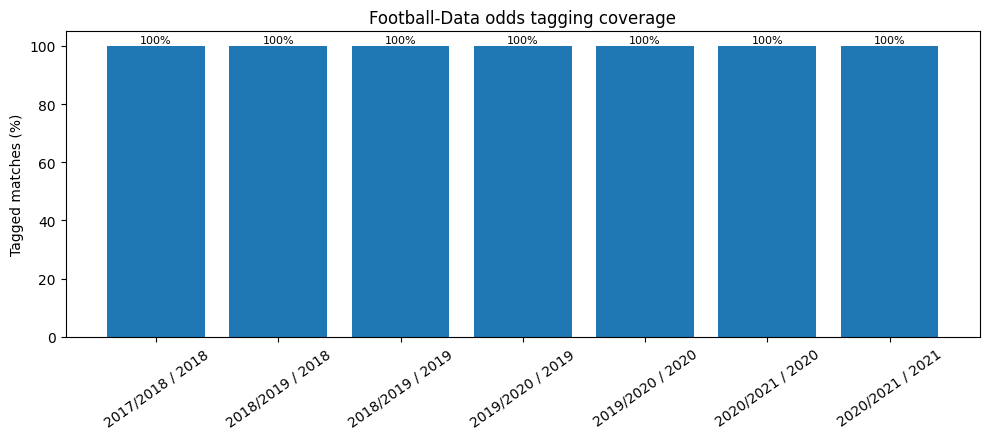

Overall tagged rows: 111/111 = 100.0%


In [9]:
# Chart 2 — Odds tagging coverage
cov = pd.read_csv(ROOT / "phase1" / "outputs" / "odds_coverage_final.csv")
cov["period"] = cov["season"].astype(str) + " / " + cov["year"].astype(str)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(cov["period"], cov["coverage_rate"] * 100)
ax.set_title("Football-Data odds tagging coverage")
ax.set_ylabel("Tagged matches (%)")
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=35)
for i, v in enumerate(cov["coverage_rate"] * 100):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print(f'Overall tagged rows: {int(result["pre"]["odds_tagged"].sum())}/{len(result["pre"])} = {result["pre"]["odds_tagged"].mean():.1%}')

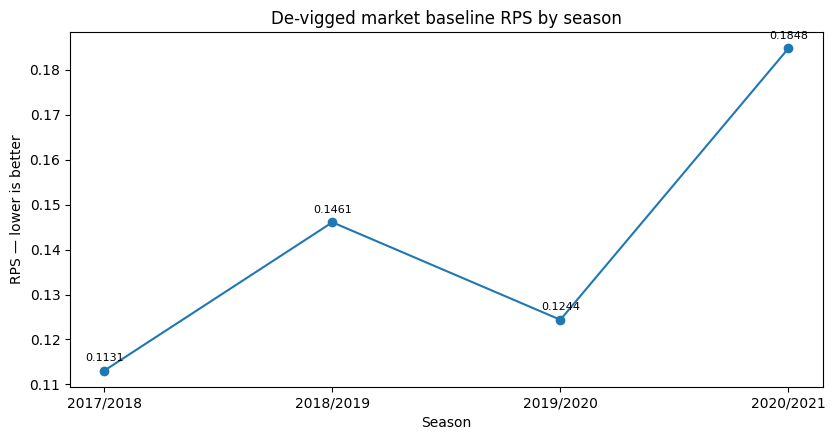

In [10]:
# Chart 3 — De-vigged market baseline across seasons
market = pd.read_csv(ROOT / "phase1" / "outputs" / "market_baseline_final.csv")
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(market["season"], market["rps"], marker="o")
ax.set_title("De-vigged market baseline RPS by season")
ax.set_ylabel("RPS — lower is better")
ax.set_xlabel("Season")
for x, y in zip(market["season"], market["rps"]):
    ax.annotate(f"{y:.4f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

### Supplemental Phase 1 diagnostics

این دو نمودار از pipeline خام داده هستند و برای توضیح distribution/correlation نگه داشته شده‌اند. نمودار تصمیم نهایی Feature Engineering همان **Chart 1** بالاست.


Class distribution by season


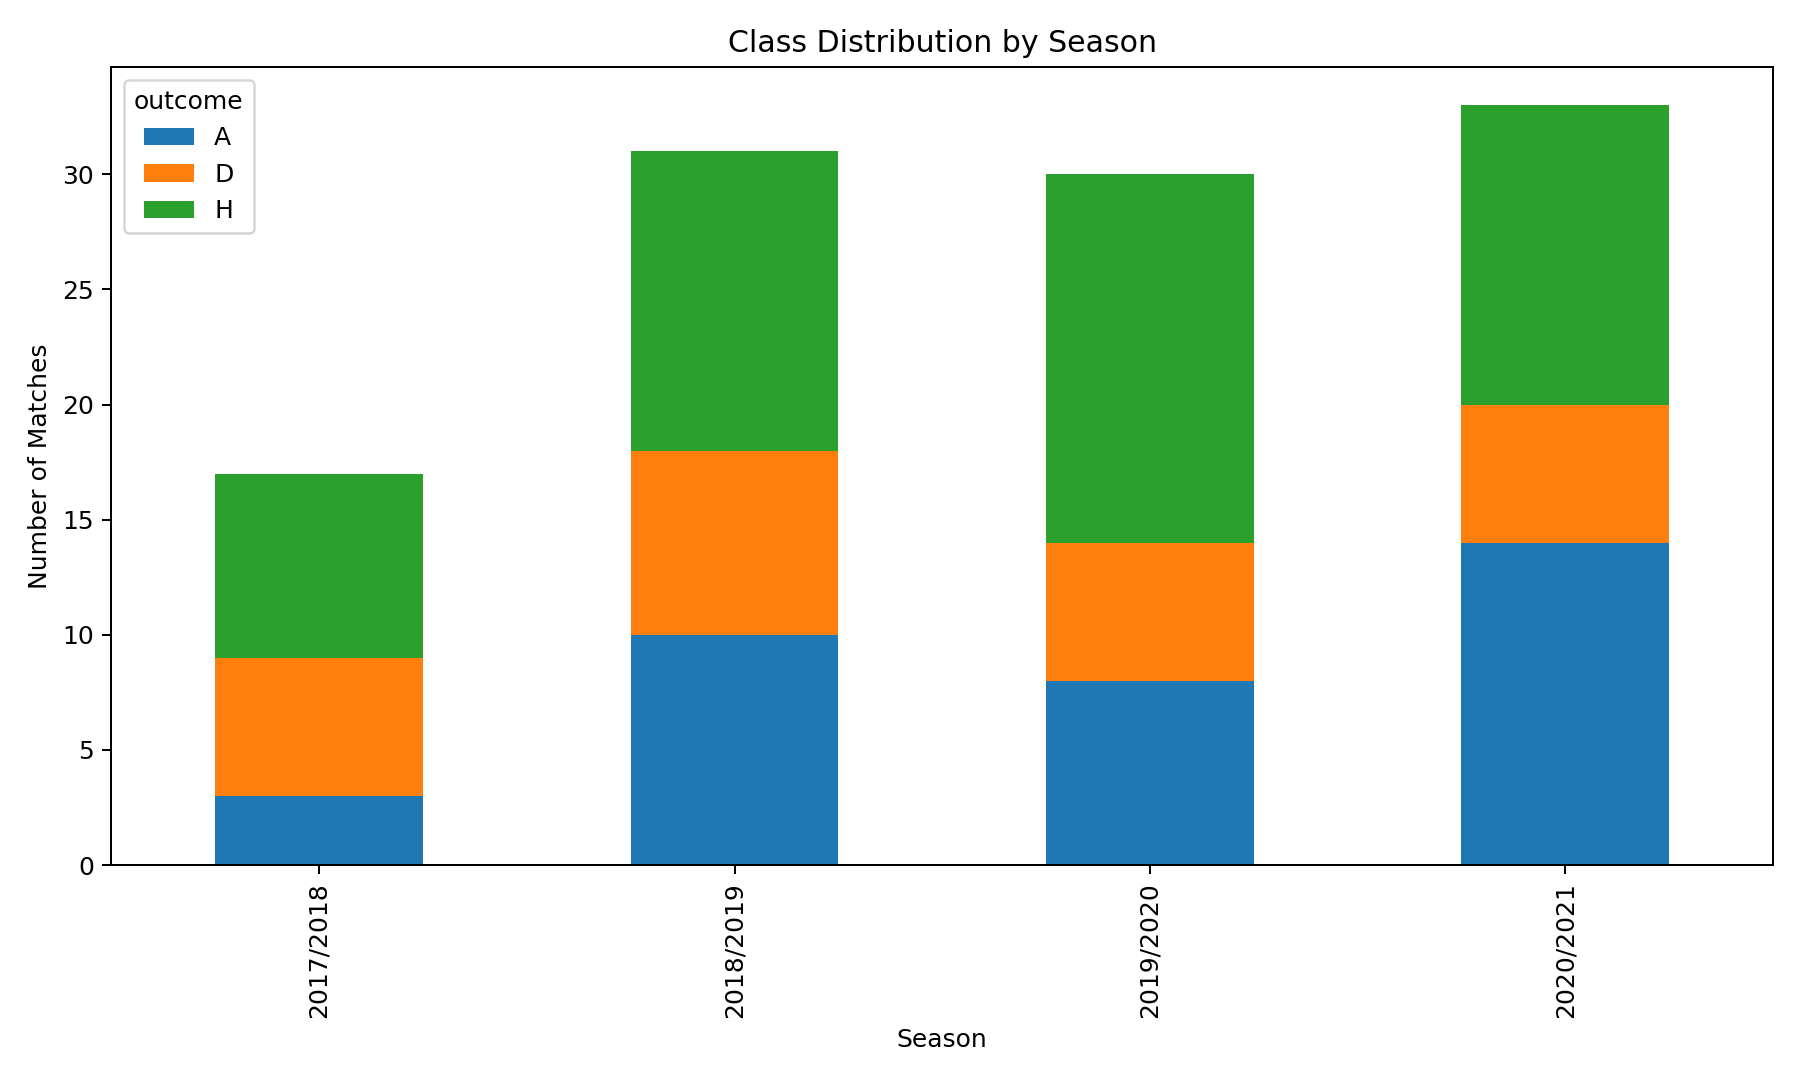


Feature correlation diagnostic


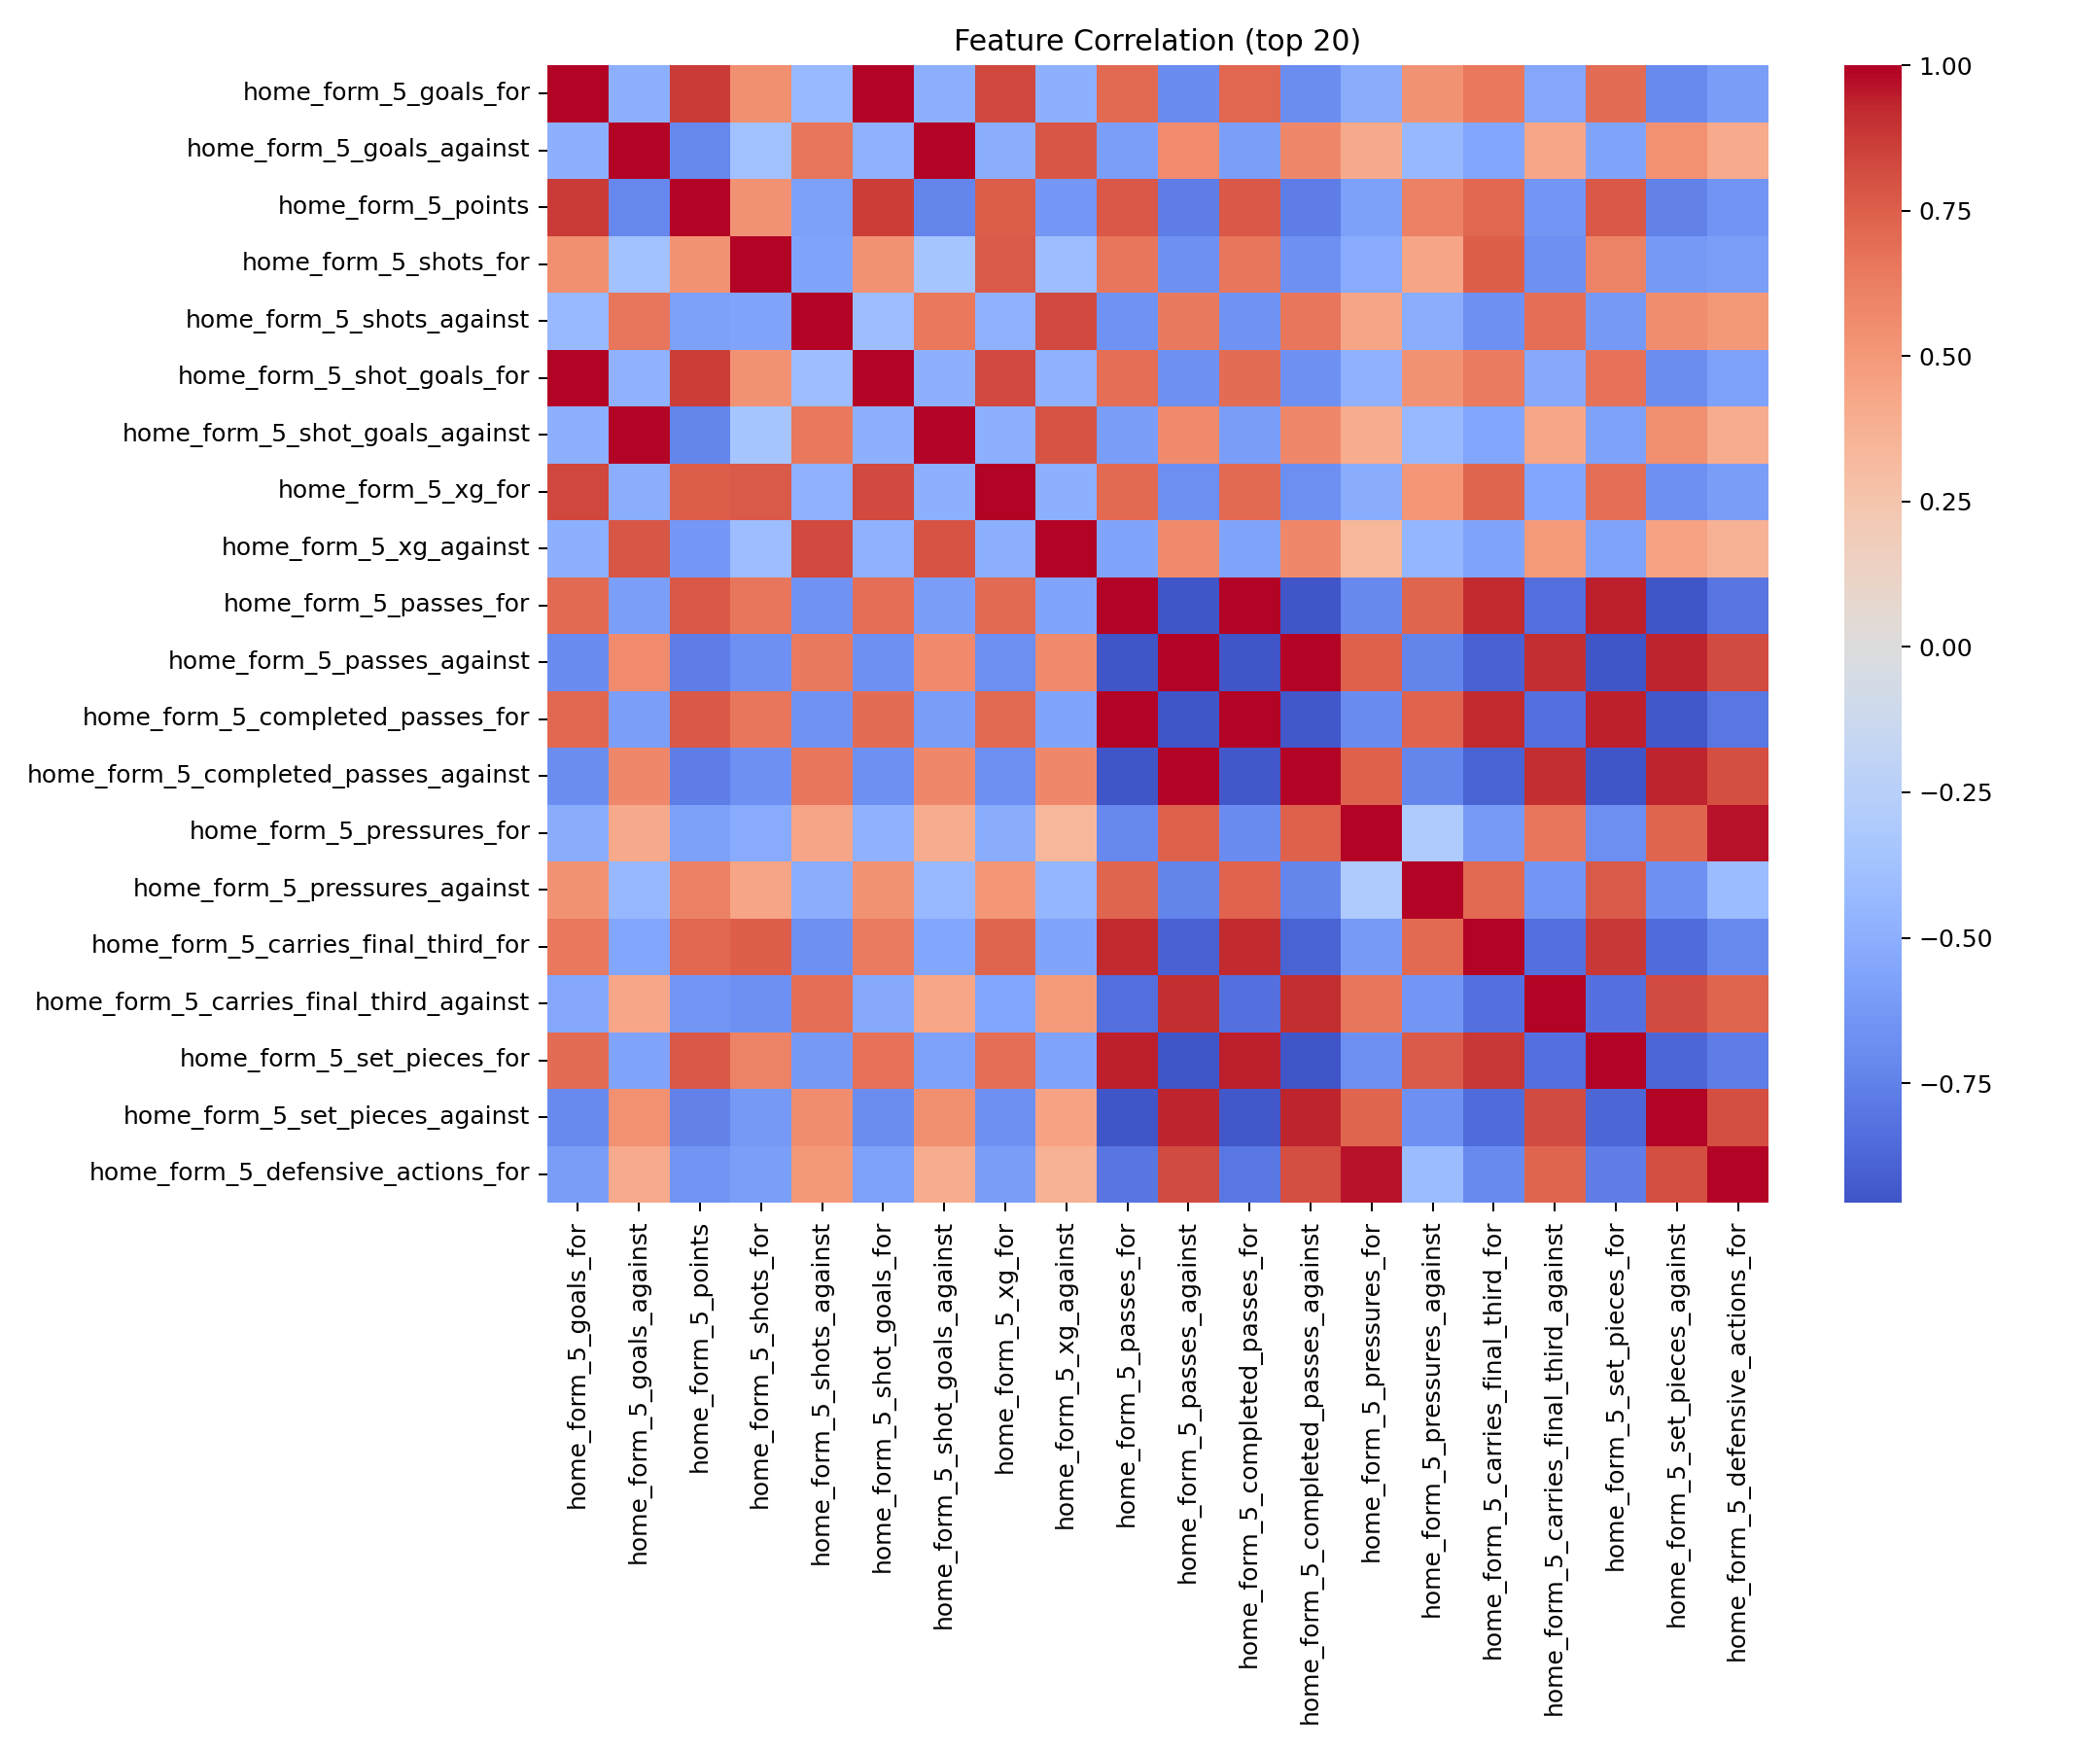

In [11]:
for filename, title in [
    ("class_distribution_by_season.png", "Class distribution by season"),
    ("feature_correlation.png", "Feature correlation diagnostic"),
]:
    p = ROOT / "phase1" / "outputs" / filename
    if p.exists():
        print("\n" + title)
        display(Image(filename=str(p)))
    else:
        print("Missing optional diagnostic:", filename)

## 7. Final Phase 1 numbers to quote in the defense

In [12]:
summary = pd.read_csv(ROOT / "phase1" / "outputs" / "final_phase1_summary.csv")
display(summary)

final_dec = pd.read_csv(ROOT / "phase1" / "outputs" / "feature_selection_decisions_final.csv")
display(final_dec[["group", "action", "mean_dev_rps", "delta_rps", "n_features_after", "reason"]].round(4))

print("PHASE1_OK")

,metric,value
0,raw_matches_cached,138
1,pre_match_modeling_rows,111
2,in_play_snapshots,1998
3,odds_tagged_rows,111
4,odds_coverage,1.0
5,selected_feature_groups,"core_form, style"
6,selected_feature_count,11
7,synthetic_rows_used,0
8,final_test_season_reserved,2020/2021


,group,action,mean_dev_rps,delta_rps,n_features_after,reason
0,momentum,REJECT,NaN,NaN,0,pre-screen rejection: mean missingness=0.423 (...
1,core_form,KEEP,0.1606,NaN,6,domain anchor: prior five-match points/goals/s...
2,style,KEEP,0.1458,0.0147,11,earned its complexity: mean future-season deve...
3,context,REJECT,0.1451,0.0007,11,no out-of-season RPS gain >= 0.0010; rejected ...
4,efficiency,REJECT,0.1471,-0.0013,11,no out-of-season RPS gain >= 0.0010; rejected ...
5,short_form,REJECT,0.1472,-0.0014,11,no out-of-season RPS gain >= 0.0010; rejected ...
6,defense_setpiece,REJECT,0.1555,-0.0096,11,no out-of-season RPS gain >= 0.0010; rejected ...


PHASE1_OK
